# 01 — Data Overview

This notebook loads and inspects the collected Google Trends data.

**Goals:**
- Find the latest data collection folder
- Verify metadata and file hashes
- Count files per country and category
- Identify missing data
- Preview sample data

⚠️ This notebook does NOT perform any analysis — only data inspection.

In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# ── Find latest data folder ────────────────────────────────────────────────────
DATA_DIR = Path('../data')
raw_folders = sorted(DATA_DIR.glob('raw_*'))

if not raw_folders:
    raise FileNotFoundError(f'No raw_* folders found in {DATA_DIR}')

LATEST = raw_folders[-1]
print(f'Latest data folder: {LATEST.name}')
print(f'Total raw folders found: {len(raw_folders)}')

Latest data folder: raw_20260417_211800
Total raw folders found: 3


## 1. Metadata

In [2]:
with open(LATEST / 'metadata.json', encoding='utf-8') as f:
    metadata = json.load(f)

print(f"Collection timestamp (UTC): {metadata['collection_timestamp_utc']}")
print(f"Timeframe: {metadata['config']['timeframe']}")
print(f"Trends category: {metadata['config']['trends_category']}")
print(f"Trends gprop: '{metadata['config']['trends_gprop']}'")
print()
print('File hashes:')
for fname, fhash in metadata['file_hashes'].items():
    print(f'  {fname}: {fhash}')
print()
print('Excluded countries:')
for code, reason in metadata['config']['excluded_countries'].items():
    print(f'  {code}: {reason}')

Collection timestamp (UTC): 20260417_211800
Timeframe: 2018-01-01 2025-12-31
Trends category: 0
Trends gprop: ''

File hashes:
  keywords.json: 2526da0f44a6b1b48e0408ca9bd72a124b99df0cafcf9bdb5b232df9bb0e2a69
  config.py: 7cfd962b8ce11ecde1650b49ef0f80cedb2ec541c76df5632010a60f32b97f2a

Excluded countries:
  RU: Search censorship distorts data
  BY: Search censorship distorts data


## 2. Files per country

In [3]:
country_dirs = sorted([d for d in LATEST.iterdir() if d.is_dir()])
print(f'Countries with data: {len(country_dirs)}')
print()

summary = []
for country_dir in country_dirs:
    csv_files = list(country_dir.glob('*.csv'))
    json_files = list(country_dir.glob('*.json'))
    summary.append({
        'country': country_dir.name,
        'csv_files': len(csv_files),
        'related_query_files': len(json_files),
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print()
print(f'Total CSV files: {df_summary["csv_files"].sum()}')

Countries with data: 21

country  csv_files  related_query_files
     AM         11                    8
     AU         10                    5
     AZ         13                    8
     BR         10                    5
     CA         10                    5
     DE         16                    8
     EE         17                   11
     FR         16                    8
     GB         10                    5
     GE         12                    8
     IL          9                    5
     JP         10                    5
     KZ         14                    8
     LT         15                   11
     LV         16                   11
     MD         15                    8
     NL         16                    8
     PL         16                    8
     UA         21                   11
     US         10                    5
     UZ         12                    8

Total CSV files: 279


## 3. Missing data overview

In [4]:
missing = []
present = []

for country_dir in country_dirs:
    for csv_file in country_dir.glob('*.csv'):
        df = pd.read_csv(csv_file, index_col=0)
        parts = csv_file.stem.split('__')
        if len(parts) >= 2:
            category = parts[0]
            language = parts[1]
        
        if df.empty:
            missing.append({
                'country': country_dir.name,
                'file': csv_file.name,
                'category': category,
                'language': language,
            })
        else:
            present.append({
                'country': country_dir.name,
                'file': csv_file.name,
                'category': category,
                'language': language,
                'rows': len(df),
                'columns': len(df.columns),
            })

print(f'Files with data: {len(present)}')
print(f'Empty files (no data returned): {len(missing)}')

if missing:
    print()
    print('Missing data files:')
    df_missing = pd.DataFrame(missing)
    print(df_missing.to_string(index=False))

Files with data: 279
Empty files (no data returned): 0


## 4. Sample data — Ukraine

In [5]:
ua_dir = LATEST / 'UA'
ua_files = sorted(ua_dir.glob('*.csv'))

print(f'Ukraine CSV files: {len(ua_files)}')
print()
for f in ua_files:
    print(f'  {f.name}')

Ukraine CSV files: 21

  evidence_based_treatments__en__chunk1.csv
  evidence_based_treatments__en__chunk2.csv
  evidence_based_treatments__latin_abbrev__chunk1.csv
  evidence_based_treatments__latin_abbrev__chunk2.csv
  evidence_based_treatments__latin_abbrev__chunk3.csv
  evidence_based_treatments__ru__chunk1.csv
  evidence_based_treatments__ru__chunk2.csv
  evidence_based_treatments__ru__chunk3.csv
  evidence_based_treatments__uk__chunk1.csv
  evidence_based_treatments__uk__chunk2.csv
  evidence_based_treatments__uk__chunk3.csv
  general_help_seeking__en__chunk1.csv
  general_help_seeking__ru__chunk1.csv
  general_help_seeking__uk__chunk1.csv
  general_help_seeking__uk__chunk2.csv
  specific_conditions__en__chunk1.csv
  specific_conditions__latin_abbrev__chunk1.csv
  specific_conditions__ru__chunk1.csv
  specific_conditions__ru__chunk2.csv
  specific_conditions__uk__chunk1.csv
  specific_conditions__uk__chunk2.csv


In [6]:
# Preview first Ukraine file
first_ua = ua_files[0]
df_ua = pd.read_csv(first_ua, index_col=0, parse_dates=True)
print(f'File: {first_ua.name}')
print(f'Shape: {df_ua.shape}')
print(f'Date range: {df_ua.index.min()} — {df_ua.index.max()}')
print()
df_ua.head(10)

File: evidence_based_treatments__en__chunk1.csv
Shape: (96, 5)
Date range: 2018-01-01 00:00:00 — 2025-12-01 00:00:00



,cognitive behavioral therapy,eye movement desensitization and reprocessing,dialectical behavior therapy,acceptance and commitment therapy,cognitive processing therapy
date,,,,,
2018-01-01,0,0,0,0,0
2018-02-01,0,0,0,0,0
2018-03-01,0,0,0,0,0
2018-04-01,0,0,0,0,0
2018-05-01,0,0,0,0,0
2018-06-01,0,0,0,0,0
2018-07-01,0,0,0,0,0
2018-08-01,0,0,0,0,0
2018-09-01,0,0,0,0,0


## 5. Quick visualization — Ukraine sample

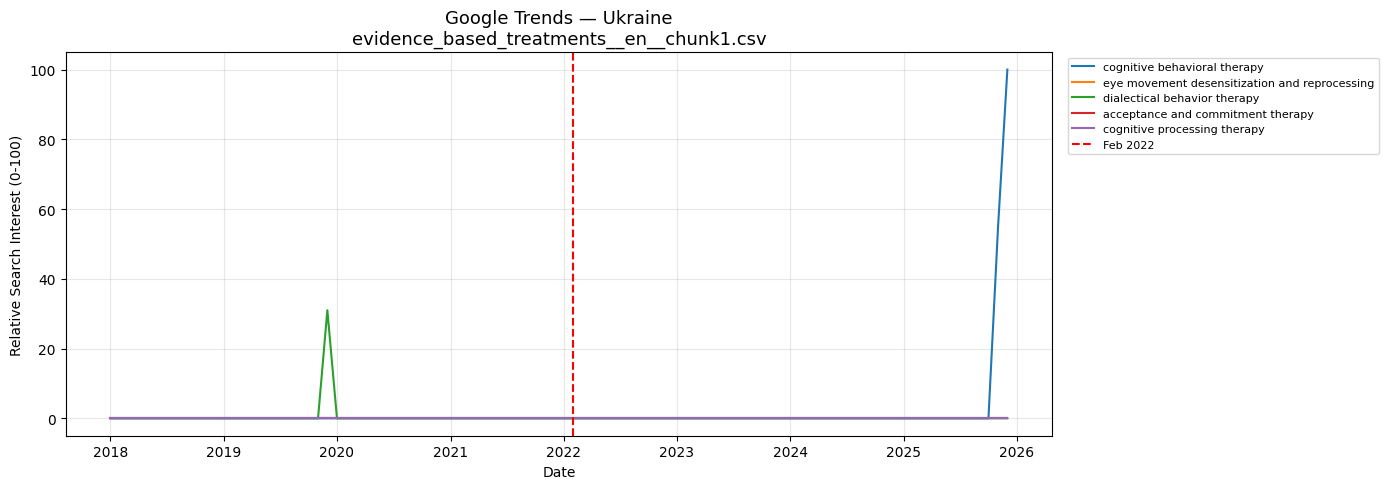

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for col in df_ua.columns:
    ax.plot(df_ua.index, df_ua[col], label=col, linewidth=1.5)

# Mark February 2022
ax.axvline(pd.Timestamp('2022-02-01'), color='red', linestyle='--', 
           linewidth=1.5, label='Feb 2022')

ax.set_title(f'Google Trends — Ukraine\n{first_ua.name}', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Relative Search Interest (0-100)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary statistics

In [8]:
df_present = pd.DataFrame(present)

print('Rows per country (mean across files):')
print(df_present.groupby('country')['rows'].mean().round(1).to_string())
print()
print('Files per category:')
print(df_present.groupby('category')['file'].count().to_string())

Rows per country (mean across files):
country
AM    96.0
AU    96.0
AZ    96.0
BR    96.0
CA    96.0
DE    96.0
EE    96.0
FR    96.0
GB    96.0
GE    96.0
IL    96.0
JP    96.0
KZ    96.0
LT    96.0
LV    96.0
MD    96.0
NL    96.0
PL    96.0
UA    96.0
US    96.0
UZ    96.0

Files per category:
category
evidence_based_treatments    158
general_help_seeking          40
specific_conditions           81
